In [2]:
# setup
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline     import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute        import SimpleImputer
from sklearn.linear_model  import Lasso
from sklearn.ensemble      import RandomForestRegressor
from sklearn.metrics       import r2_score, mean_squared_error

RANDOM_STATE = 123

PROJECT_DIR = r"C:\Users\User\Desktop\KU Leuven. Msc Statistics. Year 1\Modern Data Analytics"
os.chdir(PROJECT_DIR)
sys.path.append(PROJECT_DIR)

from load_cycling_weather_data import load_columns, load_sample, load_date_range, load_one_site, peek

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [5]:
df = load_columns(["ts", "site_id", "direction", "count", "precip_quantity", "temp_dry_shelter_avg", "wind_speed_10m",
                   "wind_gusts_speed", "humidity_rel_shelter_avg", "short_wave_from_sky_avg", "nearest_station_km",
                   "site_lat", "site_lon"])
df["ts"] = pd.to_datetime(df["ts"], utc=True)
df["count"] = df["count"].clip(lower=0)
df["date"] = df["ts"].dt.date
df["hour"] = df["ts"].dt.hour
df["weekday"] = df["ts"].dt.weekday
df["weekend"] = df["weekday"].isin([5, 6]).astype(int)
df["month"] = df["ts"].dt.month
df["rain"] = (df["precip_quantity"] > 0).astype(int)
df["heavy_rain"] = (df["precip_quantity"] >= 1).astype(
    int)  # heavy rain dummy, more than 1mm considered to be heavy rain
df["commute_hour"] = df["hour"].isin([7, 8, 16, 17, 18]).astype(int)
df["log_count"] = np.log1p(df["count"])

display(df.head())

print(df.shape)

,ts,site_id,direction,count,precip_quantity,temp_dry_shelter_avg,wind_speed_10m,wind_gusts_speed,humidity_rel_shelter_avg,short_wave_from_sky_avg,nearest_station_km,site_lat,site_lon,date,hour,weekday,weekend,month,rain,heavy_rain,commute_hour,log_count
0,2019-10-21 05:45:00+00:00,17,OUT,0.0,0.0,11.028842,3.496171,5.590133,100.000000,0.000000,13.472666,50.83339,3.27773,2019-10-21,5,0,0,10,0,0,0,0.0
1,2019-10-21 22:15:00+00:00,17,OUT,0.0,0.0,12.588762,2.926754,4.311200,98.532102,0.000000,13.472666,50.83339,3.27773,2019-10-21,22,0,0,10,0,0,0,0.0
2,2019-10-21 21:15:00+00:00,17,OUT,0.0,0.0,12.285123,2.258512,3.729867,97.393643,0.000000,13.472666,50.83339,3.27773,2019-10-21,21,0,0,10,0,0,0,0.0
3,2019-10-21 03:45:00+00:00,17,IN,0.0,0.0,10.682874,4.284168,6.287733,99.618674,0.000000,13.472666,50.83339,3.27773,2019-10-21,3,0,0,10,0,0,0,0.0
4,2019-10-21 16:30:00+00:00,17,OUT,0.0,0.0,12.991455,1.791847,2.683467,91.448280,5.721491,13.472666,50.83339,3.27773,2019-10-21,16,0,0,10,0,0,1,0.0


(40708210, 22)


In [7]:
# saving my memory 
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].astype('float32')

for col in ['rain', 'heavy_rain', 'weekend', 'commute_hour']:
    df[col] = df[col].astype('int8')

df_small = df.sample(frac=0.50, random_state=123)

In [8]:
df_small = df_small.dropna(subset=["count", "log_count"])

df_small = df_small.dropna(subset=["precip_quantity", "temp_dry_shelter_avg"], how="all")

print(f"Rows after cleaning: {df_small.shape[0]}")
print(f"NaNs in log_count: {df_small['log_count'].isna().sum()}")

Rows after cleaning: 19833212
NaNs in log_count: 0


In [ ]:
# feature matrix X and target vector y
# we predict log_count (more stable than raw count)
FEATURES = [
    "precip_quantity",       # main variable of interest (rainfall)
    "temp_dry_shelter_avg",  # temperature
    "wind_speed_10m",        # wind
    "wind_gusts_speed",
    "humidity_rel_shelter_avg",
    "short_wave_from_sky_avg",
    "hour",                  # time-of-day
    "weekday",
    "weekend",
    "month",
    "commute_hour",
    "rain",
    "heavy_rain",
    "nearest_station_km",
]

X = df_small[FEATURES].copy()
y = df_small["log_count"].copy()

print(f"Feature matrix X: {X.shape}")
print(f"Target vector y:  {y.shape}")
display(X.head())

Feature matrix X: (19833212, 14)
Target vector y:  (19833212,)


,precip_quantity,temp_dry_shelter_avg,wind_speed_10m,wind_gusts_speed,humidity_rel_shelter_avg,short_wave_from_sky_avg,hour,weekday,weekend,month,commute_hour,rain,heavy_rain,nearest_station_km
10435929,0.00,3.229566,5.344772,7.718089,86.266815,56.765282,12,4,0,1,0,0,0,30.984329
26401981,0.00,13.188980,NaN,0.997600,88.487251,0.000000,19,6,1,9,0,0,0,5.332774
10680616,0.00,3.349840,2.383789,3.904267,86.371552,0.000000,22,0,0,1,0,0,0,5.006357
11704872,0.03,4.319822,3.593544,4.950667,89.756531,127.493195,12,1,0,3,0,1,0,18.448673
40626371,0.00,6.129324,4.534286,7.101600,93.416237,259.270142,12,0,0,2,0,0,0,18.331869


In [ ]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")

Training set:  (15866569, 14)
Test set:      (3966643, 14)


In [17]:
# Lasso regression
# build pipeline
lasso_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),   # handle NaNs in weather data
    ("scaler",  StandardScaler()),                 # required before Lasso
    ("model",   Lasso(random_state=RANDOM_STATE, max_iter=5000))
])

# hyperparameter grid (to find the best regularisation strenght)
lasso_params = {
    "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0]
}

# grid search with cross-validation
lasso_gs = GridSearchCV(
    lasso_pipe,
    param_grid=lasso_params,
    cv=5,
    scoring="r2",
    verbose=1,
    n_jobs=1 # one at a time
)
lasso_gs.fit(X_train, y_train)

print(f"Best alpha: {lasso_gs.best_params_}")
print(f"Best CV R²: {lasso_gs.best_score_:.3f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best alpha: {'model__alpha': 0.001}
Best CV R²: 0.164


In [19]:
# evaluate on unseen test set 
y_pred_lasso = lasso_gs.predict(X_test)

r2_lasso  = r2_score(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

print(f"Lasso  R² on test set: {r2_lasso:.3f}")
print(f"Lasso MSE on test set: {mse_lasso:.3f}")

Lasso  R² on test set: 0.165
Lasso MSE on test set: 0.704


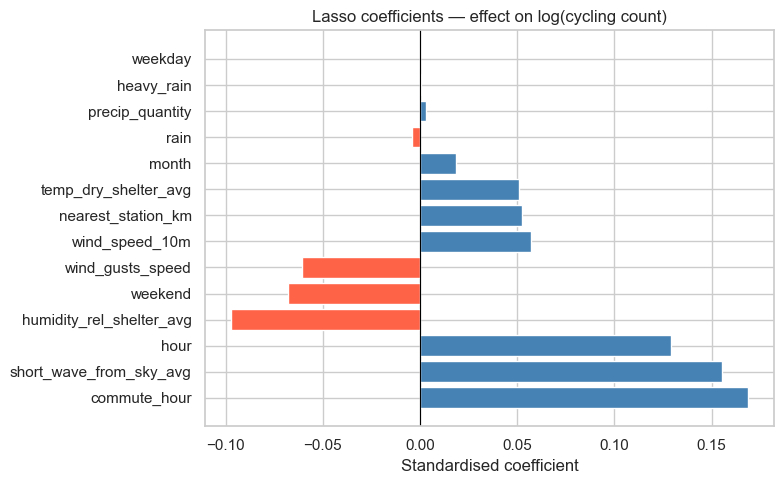

,feature,coefficient
10,commute_hour,0.168792
5,short_wave_from_sky_avg,0.155157
6,hour,0.128871
4,humidity_rel_shelter_avg,-0.097313
8,weekend,-0.067731
3,wind_gusts_speed,-0.060696
2,wind_speed_10m,0.057292
13,nearest_station_km,0.052246
1,temp_dry_shelter_avg,0.051167
9,month,0.018754


In [20]:
# inspect coefficients (the 'cost' of each weather variable) 
best_lasso = lasso_gs.best_estimator_.named_steps["model"]
coef_df = (
    pd.DataFrame({"feature": FEATURES, "coefficient": best_lasso.coef_})
    .sort_values("coefficient", key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["steelblue" if c > 0 else "tomato" for c in coef_df["coefficient"]]
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardised coefficient")
ax.set_title("Lasso coefficients — effect on log(cycling count)")
plt.tight_layout()
plt.show()

display(coef_df)

In [ ]:

# Random Forest
# First go small and find best parameters, then retrain
X_train_2= X_train.sample(n=50_000, random_state=RANDOM_STATE)
y_train_2 = y_train.loc[X_train_2.index]

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model",   RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        max_samples=0.5,
        max_features=0.5
    ))
])

rf_params = {
    "model__n_estimators": [50, 100],
    "model__max_depth":    [10, 20]
}

rf_gs = GridSearchCV(
    rf_pipe,
    param_grid=rf_params,
    cv=3,          
    scoring="r2",
    verbose=1,
    n_jobs=1
)
rf_gs.fit(X_train_2, y_train_2)

print(f"Best params: {rf_gs.best_params_}")
print(f"Best CV R²:  {rf_gs.best_score_:.3f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'model__max_depth': 20, 'model__n_estimators': 100}
Best CV R²:  0.324


In [ ]:
# retrain best model on more data
best_rf = rf_gs.best_estimator_
best_rf.fit(
    X_train.sample(n=200_000, random_state=RANDOM_STATE),
    y_train.loc[X_train.sample(n=200_000, random_state=RANDOM_STATE).index]
)

y_pred_rf = best_rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"R² on test set: {r2_rf:.3f}")

R² on test set: 0.403


In [13]:
# evaluate on test set 
y_pred_rf = rf_gs.predict(X_test)

r2_rf  = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"Random Forest  R² on test set: {r2_rf:.3f}")
print(f"Random Forest MSE on test set: {mse_rf:.3f}")

Random Forest  R² on test set: 0.403
Random Forest MSE on test set: 0.503


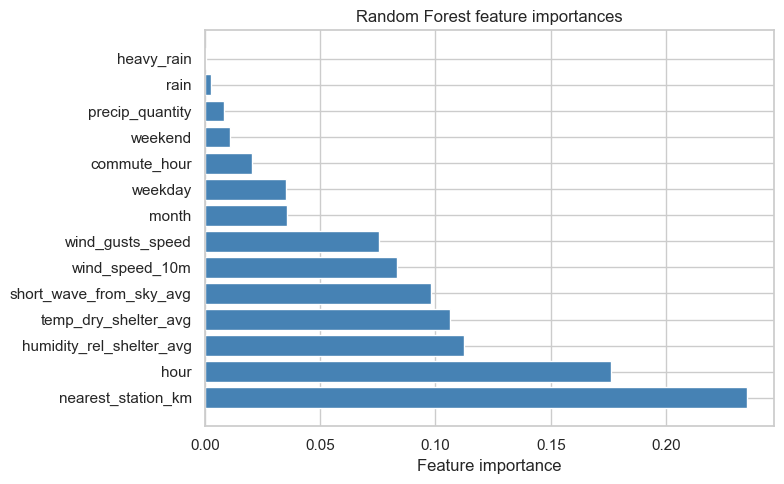

,feature,importance
13,nearest_station_km,0.235074
6,hour,0.176002
4,humidity_rel_shelter_avg,0.112569
1,temp_dry_shelter_avg,0.106194
5,short_wave_from_sky_avg,0.098142
2,wind_speed_10m,0.083276
3,wind_gusts_speed,0.075432
9,month,0.035435
7,weekday,0.035127
10,commute_hour,0.020562


In [15]:
# feature importance (captures interaction effects like rain × weekend) 
best_rf = rf_gs.best_estimator_.named_steps["model"]
imp_df = (
    pd.DataFrame({"feature": FEATURES, "importance": best_rf.feature_importances_})
    .sort_values("importance", ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp_df["feature"], imp_df["importance"], color="steelblue")
ax.set_xlabel("Feature importance")
ax.set_title("Random Forest feature importances")
plt.tight_layout()
plt.show()

display(imp_df)

In [19]:
df.columns

Index(['ts', 'site_id', 'direction', 'count', 'precip_quantity', 'temp_dry_shelter_avg', 'wind_speed_10m', 'wind_gusts_speed',
       'humidity_rel_shelter_avg', 'short_wave_from_sky_avg', 'nearest_station_km', 'site_lat', 'site_lon', 'date', 'hour', 'weekday',
       'weekend', 'month', 'rain', 'heavy_rain', 'commute_hour', 'log_count'],
      dtype='str')

In [22]:
print(df["site_id"].nunique())        # 150 — total sites in your data
  

150
